In [1]:
import os
import sys

# 파이썬 파일들이 있는 폴더로 현재 작업 경로를 이동합니다.
target_folder = 'src'
if os.path.basename(os.getcwd()) != target_folder:
    os.chdir(target_folder)

print("현재 작업 경로:", os.getcwd())

from dotenv import load_dotenv
load_dotenv(override=True)

from infrastructure.graph_db.client import OxigraphClient
from agent.graph import app
import agent.nodes as nodes
import json


현재 작업 경로: c:\Users\rladl\Desktop\2026_MIRAE_ASSET_AI-Festival\2026_10th_MIRAE-ASSET_AI-Festival\src


In [2]:
# 재시도(LLM as a judge) 로직이 실제로 로드됐는지 확인하는 셀.
_required = ["_run_sql_with_retry", "_fix_sql", "DEFAULT_MAX_SQL_RETRIES"]
_missing = [name for name in _required if not hasattr(nodes, name)]

if _missing:
    print("⚠️  경고: nodes 모듈에 재시도 로직이 없습니다:", _missing)
    print("   -> sql_gen_test/agent/nodes.py가 최신 파일인지 다시 확인하세요.")
    print("   -> 파일을 방금 바꿨다면 커널을 재시작하고 이 노트북을 처음부터 다시 실행하세요.")
else:
    print(f"재시도 로직 로드 확인됨. 기본 재시도 횟수(DEFAULT_MAX_SQL_RETRIES): {nodes.DEFAULT_MAX_SQL_RETRIES}회")


재시도 로직 로드 확인됨. 기본 재시도 횟수(DEFAULT_MAX_SQL_RETRIES): 3회


In [3]:
#  DB 통신 방식 점검: RDB / GraphDB / VectorDB가 지금 로컬/API/원격DB 중 무엇을 쓰는지 확인 
'''
이 셀은 각 DB 클라이언트가 실제로 판정에 쓰는 것과 동일한 로직(환경변수 우선순위)을 그대로 호출해서 보여줍니다.

- RDB: src/agent/utils.py가 항상 원격 SQL API(RDB_API_BASE_URL, 기본 http://40.82.145.44:8000/db/sql)로만 통신합니다. 직접 DB 접속 경로는 없음
- GraphDB: OXIGRAPH_REMOTE_STORE_PATH(원격 VM 마운트) → OXIGRAPH_LOCAL_STORE_PATH(로컬 파일) → OXIGRAPH_FALLBACK_ENDPOINT(원격 HTTP) 순서로 failover
- VectorDB: DATABASE_URL 또는 PGDATABASE가 있으면 psycopg2로 원격 PostgreSQL에 직접 접속하고, 없으면 RDB와 같은 SQL API로 전환
'''


print("=" * 70)
print("[RDB] agent.utils")
print("=" * 70)
from agent import utils
print("transport      : SQL API 고정 (requests.Session -> POST /db/sql)")
print("RDB_API_BASE_URL:", utils.RDB_API_BASE_URL)
print("RDB_API_KEY set:", bool(os.getenv("RDB_API_KEY")))

print()
print("=" * 70)
print("[GraphDB] infrastructure.graph_db.client (3단계 failover)")
print("=" * 70)
gc = OxigraphClient()
print("1순위 원격 마운트 경로:", gc.remote_store_path, "->", gc.remote_store_path and gc.remote_store_path.is_dir())
print("2순위 로컬 경로      :", gc.local_store_path, "->", gc.local_store_path.is_dir())
print("3순위 원격 HTTP endpoint:", gc.endpoint)
print("triple_count():", gc.triple_count())

try:
    from infrastructure.graph_db.client import GraphDBClient
    gc = GraphDBClient()
    n = gc.triple_count()
    print(f"-> 실제 선택된 transport로 triple_count() 성공: {n}건")
except Exception as e:
    print(f"-> triple_count() 실패: {type(e).__name__}: {e}")


print()
print("=" * 70)
print("[VectorDB] infrastructure.vector_db.client")
print("=" * 70)
has_direct = bool(os.getenv("DATABASE_URL") or os.getenv("PGDATABASE"))
print("transport      :", "직접 PostgreSQL 연결(psycopg2)" if has_direct else "read-only SQL API(RDB와 동일 엔드포인트)")
if has_direct:
    print("PGHOST:PGPORT/PGDATABASE:", os.getenv("PGHOST"), "/", os.getenv("PGPORT"), "/", os.getenv("PGDATABASE"))
print("VECTOR_SCHEMA  :", os.getenv("VECTOR_SCHEMA", "vec"))
try:
    from infrastructure.vector_db.client import VectorDBClient
    vc = VectorDBClient()
    rows = vc._run_read_sql("SELECT 1 AS ok")
    print("-> 실제 선택된 transport로 연결 확인 성공:", rows)
except Exception as e:
    print(f"-> 연결 확인 실패: {type(e).__name__}: {e}")

[RDB] agent.utils
transport      : SQL API 고정 (requests.Session -> POST /db/sql)
RDB_API_BASE_URL: http://40.82.145.44:8000
RDB_API_KEY set: False

[GraphDB] infrastructure.graph_db.client (3단계 failover)
1순위 원격 마운트 경로: None -> None
2순위 로컬 경로      : C:\Users\rladl\Desktop\2026_MIRAE_ASSET_AI-Festival\2026_10th_MIRAE-ASSET_AI-Festival\artifacts\oxigraph -> True
3순위 원격 HTTP endpoint: http://40.82.145.44:55001/query
triple_count(): 1169374
-> triple_count() 실패: ImportError: cannot import name 'GraphDBClient' from 'infrastructure.graph_db.client' (c:\Users\rladl\Desktop\2026_MIRAE_ASSET_AI-Festival\2026_10th_MIRAE-ASSET_AI-Festival\src\infrastructure\graph_db\client.py)

[VectorDB] infrastructure.vector_db.client
transport      : 직접 PostgreSQL 연결(psycopg2)
PGHOST:PGPORT/PGDATABASE: 40.82.145.44 / 55000 / financial_agent
VECTOR_SCHEMA  : vec
-> 실제 선택된 transport로 연결 확인 성공: [{'ok': 1}]


In [4]:
import json
import uuid

def test_rdb_pipeline(question: str, max_sql_retries: int | None = None):
    print(f"▶ 테스트 질문: {question}\n" + "="*50)

    # 1. 대회 규격에 맞게 임의의 question_id 생성 후 inputs에 추가
    q_id = f"Q-{uuid.uuid4().hex[:6].upper()}"
    inputs = {
        "question_id": q_id,
        "question": question
    }
    
    if max_sql_retries is not None:
        inputs["max_sql_retries"] = max_sql_retries
        print(f"  (max_sql_retries={max_sql_retries}로 지정)")

    for output in app.stream(inputs):
        for node_name, state_update in output.items():
            print(f"\n🟢 [실행 완료 노드: {node_name}]")

            # Trace 로그 출력
            if "trace" in state_update:
                for msg in state_update["trace"]:
                    print(f"  ➜ Trace: {msg}")

            # Intent 1차 분석 노드
            if node_name == "analyze_intent":
                intent = state_update.get("intent", {})
                print("  - [1차 Intent 분석 결과]")
                print(json.dumps(intent, ensure_ascii=False, indent=4))

            # [추가됨] Intent 2차 검수 노드 (LLM as a Judge)
            elif node_name == "verify_intent":
                intent = state_update.get("intent", {})
                print("  - [2차 검수(Verify) 완료된 최종 Intent]")
                print(json.dumps(intent, ensure_ascii=False, indent=4))

            # Plan 노드
            elif node_name == "plan_query":
                plan = state_update.get("plan", [])
                route = state_update.get("route", {})
                print(f"  - 생성된 Plan 개수: {len(plan)}개")
                print(f"  - 라우팅 요약: needs_rdb={route.get('needs_rdb')}, needs_graph={route.get('needs_graph')}, needs_vector={route.get('needs_vector')}")
                if plan:
                    for i, step in enumerate(plan):
                        print(f"    [Step {i+1}] {step.get('step_id')} (엔진: {step.get('engine')}, depends_on: {step.get('depends_on')})")

            # RDB 노드
            elif node_name == "rdb_search":
                step_results = state_update.get("step_results", {})
                for step_id, res in step_results.items():
                    print(f"\n  [RDB 검색 결과 - {step_id}]")

                    attempts = res.get("sql_attempts")
                    if attempts:
                        label = f"{attempts}회 시도" + (" (재시도 있었음)" if attempts > 1 else " (1번에 성공)")
                        print(f"    🔁 SQL 실행: {label}")
                        for log_line in res.get("sql_retry_log", []):
                            indented = log_line.replace("\n", "\n         ")
                            print(f"       - {indented}")

                    if "error" in res:
                        print(f"    ❌ [오류] {res['error']}")
                    else:
                        print(f"    ✅ 조회 성공: {res.get('count')}건")
                        print(f"    - 생성된 자연어 초안: {res.get('sql_draft_nl')}")
                        print(f"    - 생성된 SQL:\n{res.get('sql')}")
                        if res.get("rows"):
                            sample = res["rows"][:2]
                            print(f"    - 데이터 샘플 (최대 2건):\n{json.dumps(sample, ensure_ascii=False, default=str, indent=4)}")
                            
            # GraphDB 검색 노드 (§7: graph_orchestrator.run() 실구현)
            elif node_name == "graph_search":
                step_results = state_update.get("step_results", {})
                for step_id, res in step_results.items():
                    print(f"\n  [GraphDB 검색 결과 - {step_id}]")
                    print(f"    - status: {res.get('status')}")
                    if res.get("note"):
                        print(f"    - note: {res.get('note')}")
                    print(f"    - rows: {len(res.get('rows') or [])}건, entity_codes: {len(res.get('entity_codes') or [])}건")
                    if res.get("rows"):
                        print(f"    - 데이터 샘플 (최대 2건):\n{json.dumps(res['rows'][:2], ensure_ascii=False, default=str, indent=4)}")
                    if res.get("sparql"):
                        print(f"    - 실행된 SPARQL:\n{res['sparql']}")

            # VectorDB 검색 노드 (문서 근거 청크 검색 - 실구현)
            elif node_name == "vector_search":
                step_results = state_update.get("step_results", {})
                for step_id, res in step_results.items():
                    print(f"\n  [VectorDB 검색 결과 - {step_id}]")
                    print(f"    - status: {res.get('status')}, count: {res.get('count')}")
                    if res.get("note"):
                        print(f"    - note: {res.get('note')}")
                    if res.get("error"):
                        print(f"    ❌ [오류] {res['error']}")
                    scope = res.get("product_scope") or {}
                    coverage = scope.get("coverage") or {}
                    print(f"    - product_scope: codes={len(scope.get('codes') or [])}건, names={len(scope.get('names') or [])}건, product_ids={scope.get('product_ids')}")
                    print(f"    - coverage: {json.dumps(coverage, ensure_ascii=False)}")
                    print(f"    - queries: {res.get('queries')}")
                    print(f"    - raw_top: {res.get('raw_top')}")
                    if res.get("topic_coverage"):
                        print(f"    - topic_coverage: {json.dumps(res['topic_coverage'], ensure_ascii=False)}")
                    for c in (res.get("chunks") or [])[:3]:
                        print(f"    - {c.get('score'):.3f} | {c.get('section_type')} | {c.get('citation_text', '')[:90]}")
                        print(f"        {c.get('chunk_text', '')[:200]}")

            # 결과 병합 노드
            elif node_name == "merge_results":
                merged = state_update.get("merged_rows", [])
                print(f"  - 병합된 최종 행 개수: {len(merged)}건")
                vector_rows = sum(1 for r in merged if r.get("_domain") == "vector")
                print(f"  - 그중 문서 근거(vector) 행: {vector_rows}건")

            # 최종 답변 생성 노드
            elif node_name == "generate_answer":
                print("\n" + "="*50)
                answer_raw = state_update.get('answer', '{}')
                try:
                    answer_json = json.loads(answer_raw)
                    print(f"🤖 최종 대회 규격 응답(JSON):")
                    print(json.dumps(answer_json, ensure_ascii=False, indent=4))
                    
                    print("\n[내용 요약]")
                    print(f"📝 think_trace (추론과정): {answer_json.get('think_trace')}")
                    print(f"💬 answer (최종답변): {answer_json.get('answer')}")
                except json.JSONDecodeError:
                    print(f"🤖 최종 답변 (JSON 파싱 실패, 원본 출력):\n{answer_raw}")
                print("="*50)

In [5]:
test_question= "미래에셋에서 운용하는 반도체 테마 국내ETF 중에서 순자산이 가장 큰 ETF는 뭐야?"
test_rdb_pipeline(test_question)

▶ 테스트 질문: 미래에셋에서 운용하는 반도체 테마 국내ETF 중에서 순자산이 가장 큰 ETF는 뭐야?

🟢 [실행 완료 노드: receive_question]
  ➜ Trace: 질문 수신: 미래에셋에서 운용하는 반도체 테마 국내ETF 중에서 순자산이 가장 큰 ETF는 뭐야?

🟢 [실행 완료 노드: analyze_intent]
  ➜ Trace: 질의 분석 완료. product_domain=['국내ETF']
  ➜ Trace: 질의 분석 보정: relations가 있는데 task='recommendation' -> 'relation'으로 재분류
  - [1차 Intent 분석 결과]
{
    "raw_question": "미래에셋에서 운용하는 반도체 테마 국내ETF 중에서 순자산이 가장 큰 ETF는 뭐야?",
    "task": "relation",
    "product_domain": [
        {
            "domain": "국내ETF",
            "subtype": [
                "테마형"
            ]
        }
    ],
    "target_entities": [],
    "conditions": [
        {
            "attribute": "운용사",
            "operator": "eq",
            "value": "미래에셋",
            "value_2": "",
            "applies_to": "target",
            "domain": "국내ETF",
            "time_window_relative": "",
            "kind": "categorical",
            "grounding_status": "resolved"
        }
    ],
    "relations": [
        {
            "id": "R1"

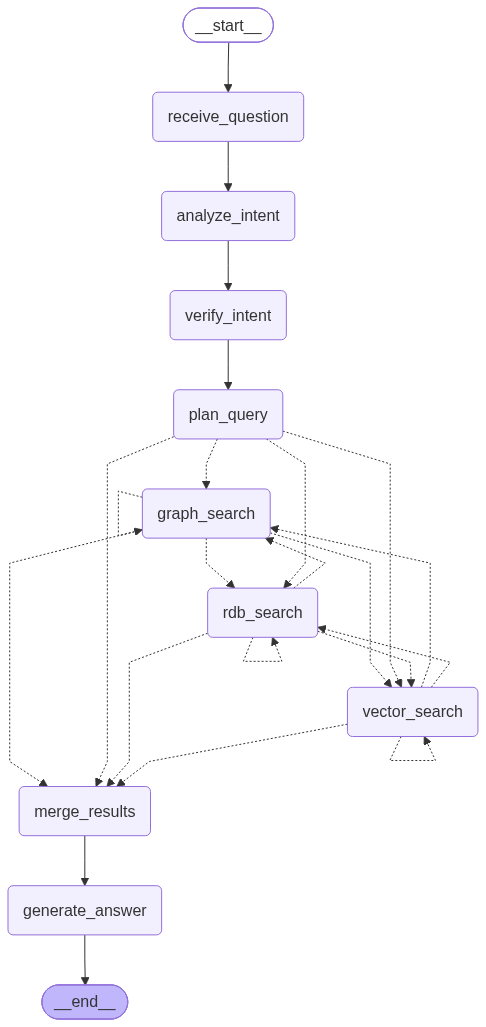

In [8]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

## Vector DB

In [9]:
# 1. 프로젝트 경로와 환경변수 설정 =============================================================
import os
import sys
from pathlib import Path

from dotenv import load_dotenv

ROOT = Path.cwd()

while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

if not (ROOT / "src").exists():
    raise RuntimeError("프로젝트 루트의 src 폴더를 찾을 수 없습니다.")

sys.path.insert(0, str(ROOT / "src"))
load_dotenv(ROOT / ".env")

os.environ.setdefault("VECTOR_SCHEMA", "vec")
os.environ.setdefault("VECTOR_DB_TIMEOUT", "60")

print("PROJECT_ROOT:", ROOT)
print("VECTOR_SCHEMA:", os.environ["VECTOR_SCHEMA"])
print(
    "VECTOR_TRANSPORT:",
    "direct PostgreSQL"
    if os.getenv("DATABASE_URL") or os.getenv("PGDATABASE")
    else "read-only SQL API",
)

PROJECT_ROOT: c:\Users\rladl\Desktop\2026_MIRAE_ASSET_AI-Festival\2026_10th_MIRAE-ASSET_AI-Festival
VECTOR_SCHEMA: vec
VECTOR_TRANSPORT: direct PostgreSQL


### V-1. vector_search_node 단독 실행 (LLM 없이 검색만)

- LangGraph 파이프라인 없이 `nodes.vector_search_node(state)`를 직접 호출해 status·count·product_scope·coverage와 상위 청크 인용이 기대대로 나오는지 확인한다.
- 문서가 확보된 상품(vec.product_coverage=matched_dart)을 질의해 정상 검색(status=ok) 흐름을 본다.

> nodes.py·tools/vector_search.py·infrastructure/vector_db/client.py를 고친 뒤에는 아래 셀의 reload 체인이 노드 단독 실행(V-1·V-2)에는 반영해 주지만, E2E(`app`, V-3·V-4)는 그래프 빌드 시점에 노드가 묶이므로 **커널 재시작 후 처음부터 실행**해야 반영된다.


In [11]:
import importlib, json
import infrastructure.vector_db.client as _vec_client
import tools.vector_search as _vec_tool
import agent.nodes as nodes
# 의존 순서대로 다시 읽는다(client -> tool -> nodes). nodes만 reload하면 tool이
# 옛 VectorDBClient를 계속 물고 있어 AttributeError가 난다(2026-09-03 실측).
for _m in (_vec_client, _vec_tool, nodes):
    importlib.reload(_m)

def run_vector_node(question, product_names, topics, fields=()):
    state = {
        "question": question,
        "intent": {"target_entities": [{"surface_form": n, "entity_type": "product_name"} for n in product_names]},
        "plan": [{"step_id": "vector_narrative", "engine": "vector", "depends_on": [], "topics": topics, "fields": list(fields)}],
        "step_results": {},
    }
    out = nodes.vector_search_node(state)
    for msg in out.get("trace", []):
        print("➜", msg)
    for step_id, res in (out.get("step_results") or {}).items():
        print(f"[{step_id}] status={res.get('status')} count={res.get('count')} note={res.get('note')}")
        if res.get("error"): print("  error:", res["error"])
        print("  scope:", json.dumps(res.get("product_scope"), ensure_ascii=False))
        print("  topic_coverage:", json.dumps(res.get("topic_coverage"), ensure_ascii=False))
        for c in (res.get("chunks") or [])[:3]:
            print(f"  {c['score']:.3f} | {c['section_type']} | {c['citation_text'][:90]}")
            print("     ", c["chunk_text"][:200].replace("\n", " "))
    return out

# 문서가 확보된 상품(vec.product_coverage=matched_dart)
_ = run_vector_node("미래에셋 TIGER 한중반도체 ETF의 투자 위험을 설명해줘",
                    ["미래에셋 TIGER 한중반도체증권상장지수투자신탁(주식-파생형)(합성)"], ["투자 위험"])

➜ VectorDB 검색 [vector_narrative]: status=ok, 1건 (스코프 1상품, 문서확보 1)
[vector_narrative] status=ok count=1 note=스코프 1상품(문서 확보 1, 미확보 0), 청크 1건(≥0.45)
  scope: {"codes": [], "names": ["미래에셋 TIGER 한중반도체증권상장지수투자신탁(주식-파생형)(합성)"], "product_ids": ["etf_kr:KR7449690007"], "coverage": {"matched": 1, "unavailable": 0, "download_failed": 0, "unknown": 0}}
  topic_coverage: {"requested": {"risk": ["투자 위험"]}, "uncovered": {}}
  0.594 | risk | 투자설명서(집합투자증권)(미래에셋TIGER한중반도체증권상장지수투자신탁(주식-파생형)(합성)) > 표지 투자위험 요약
      투자위험등급 2등급[ 높은 위험 ] | 미래에셋자산운용㈜는 이 집합투자기구의 실제 수익률 변동성 을 감안하여 2등급으로 분류 하였습니다. 펀드의 위험 등급은 운용실적, 시장 상황 등에 따라 변경될 수 있다는 점을 유의하여 투자판단을 하시기 바랍니다 금융위원회가 투자설명서의 기재사항이 진실 또는 정확하다는 것을 인정하거나 그 증권의 가치를 보증 또는 승인하지


### V-2. 문서 미확보 상품 → status=no_document

coverage가 unavailable이면 웹검색 대상이 아니라 '투자설명서 미확보'로 답해야 한다. 상품명을 지목했는데 product_master 완전일치에 실패하면 `no_product_match`로 검색을 생략한다(다른 상품 문서 인용 방지).


In [12]:
_ = run_vector_node("미래에셋 TIGER 반도체 ETF의 투자 위험을 설명해줘",
                    ["미래에셋 TIGER 반도체 증권상장지수투자신탁(주식)"], ["투자 위험"])

➜ VectorDB 검색 [vector_narrative]: status=no_document, 0건 (스코프 1상품, 문서확보 0), 미확보 주제 1건
[vector_narrative] status=no_document count=0 note=스코프 1상품(문서 확보 0, 미확보 1), 청크 0건(≥0.45), 요청 주제 미확보: 투자 위험(투자위험 섹션 없음)
  scope: {"codes": [], "names": ["미래에셋 TIGER 반도체 증권상장지수투자신탁(주식)"], "product_ids": ["etf_kr:KR7091230003"], "coverage": {"matched": 0, "unavailable": 1, "download_failed": 0, "unknown": 0}}
  topic_coverage: {"requested": {"risk": ["투자 위험"]}, "uncovered": {"risk": ["투자 위험"]}}


### V-2b. 요청 주제 섹션 부재 → status=topic_not_covered / 전략 섹션 보유 상품 → ok

- 문서 974건 중 847건은 `risk`(표지 투자위험 요약) 청크뿐이다(2026-09-03 실측). 요청 주제(`topics`·`fields`)를 `section_type` 힌트로 바꿔 검색을 제한하므로, 운용 전략을 물었는데 전략 섹션이 없으면 위험 청크를 대신 인용하지 않고 `topic_not_covered`로 남긴다.
- 전략 섹션(`objective_strategy`)이 실제로 적재된 상품은 정상(`ok`)으로 전략 청크가 나와야 한다.

In [13]:
# 문서는 있으나(표지 투자위험 요약) 운용 전략 섹션이 없는 펀드 -> topic_not_covered
_ = run_vector_node("미래에셋개인연금글로벌인컴증권전환형자투자신탁1호(채권혼합)의 운용 전략을 설명해줘",
                    ["미래에셋개인연금글로벌인컴증권전환형자투자신탁1호(채권혼합)"], ["운용 전략"], fields=["운용 전략"])
print()
# objective_strategy 청크가 82건 적재된 ETF -> ok, 전략 섹션 청크 인용
_ = run_vector_node("삼성액티브 KoAct AI인프라액티브증권상장지수투자신탁[주식]의 운용 전략을 설명해줘",
                    ["삼성액티브 KoAct AI인프라액티브증권상장지수투자신탁[주식]"], ["운용 전략"], fields=["운용 전략"])

➜ VectorDB 검색 [vector_narrative]: status=topic_not_covered, 0건 (스코프 1상품, 문서확보 1), 미확보 주제 1건
[vector_narrative] status=topic_not_covered count=0 note=스코프 1상품(문서 확보 1, 미확보 0), 청크 0건(≥0.45), 요청 주제 미확보: 운용 전략(투자목적·운용전략 섹션 없음)
  scope: {"codes": [], "names": ["미래에셋개인연금글로벌인컴증권전환형자투자신탁1호(채권혼합)"], "product_ids": ["fund:KR510904089M"], "coverage": {"matched": 1, "unavailable": 0, "download_failed": 0, "unknown": 0}}
  topic_coverage: {"requested": {"objective_strategy": ["운용 전략"]}, "uncovered": {"objective_strategy": ["운용 전략"]}}

➜ VectorDB 검색 [vector_narrative]: status=ok, 5건 (스코프 1상품, 문서확보 1)
[vector_narrative] status=ok count=5 note=스코프 1상품(문서 확보 1, 미확보 0), 청크 5건(≥0.45)
  scope: {"codes": [], "names": ["삼성액티브 KoAct AI인프라액티브증권상장지수투자신탁[주식]"], "product_ids": ["etf_kr:KR7487130007"], "coverage": {"matched": 1, "unavailable": 0, "download_failed": 0, "unknown": 0}}
  topic_coverage: {"requested": {"objective_strategy": ["운용 전략"]}, "uncovered": {}}
  0.694 | objective_strategy | [투자설명서][변경] 삼성액티브 

### V-3. E2E — 서술형 질문 (RDB → Vector → 답변)

RDB 단계가 `pd_nm LIKE '%상품명%'`로 상품을 찾고, 그 행의 상품명을 Vector 단계가 product_id로 해소해 투자설명서 청크를 검색한다. 상품명 뒤에 ' ETF'를 붙이면 RDB LIKE가 0건이 되므로(실측) 정식 명칭으로 묻는다.
- 기대: intent가 "투자 위험"을 fields에 넣으므로 Vector 단계는 `risk` 섹션으로 제한해 검색하고(topic_coverage.requested={"risk": [...]}), 답변은 위험등급과 순자산만 답한다.

In [14]:
test_rdb_pipeline("미래에셋 TIGER 한중반도체증권상장지수투자신탁의 투자 위험과 순자산을 알려줘")


▶ 테스트 질문: 미래에셋 TIGER 한중반도체증권상장지수투자신탁의 투자 위험과 순자산을 알려줘

🟢 [실행 완료 노드: receive_question]
  ➜ Trace: 질문 수신: 미래에셋 TIGER 한중반도체증권상장지수투자신탁의 투자 위험과 순자산을 알려줘

🟢 [실행 완료 노드: analyze_intent]
  ➜ Trace: 질의 분석 완료. product_domain=['국내ETF']
  - [1차 Intent 분석 결과]
{
    "raw_question": "미래에셋 TIGER 한중반도체증권상장지수투자신탁의 투자 위험과 순자산을 알려줘",
    "task": "explanation",
    "product_domain": [
        {
            "domain": "국내ETF",
            "subtype": [
                "증권",
                "상장지수",
                "투자신탁"
            ]
        }
    ],
    "target_entities": [
        {
            "surface_form": "미래에셋 TIGER 한중반도체증권상장지수투자신탁",
            "entity_type": "product_name"
        }
    ],
    "conditions": [],
    "relations": [],
    "sort": {
        "attribute": "",
        "order": "",
        "limit": "",
        "domains": []
    },
    "output_requirements": {
        "fields": [
            "투자 위험",
            "순자산"
        ],
        "narrative_topics": []
    },
    "answer_format": "narr

### V-4. E2E — 펀드 서술형(요청 주제 문서 부재)

- 이 펀드의 투자설명서 청크는 표지 투자위험 요약(`risk`) 하나뿐이다. 이전(2026-09-03 오전)에는 이 위험 청크가 0.578점으로 floor를 넘겨 `ok`로 통과했고 최종 답변이 운용 전략 대신 위험등급을 설명하는 오답이 났다.
- 수정 후 기대: Vector 단계 `status=topic_not_covered`, `topic_coverage.uncovered={"objective_strategy": ["운용 전략"]}`, 최종 answer는 "운용 전략 관련 문서를 확인할 수 없음"(사유 포함)이어야 하며 위험등급·예금자보호 문구로 대체 답변하면 안 된다.

In [15]:
test_rdb_pipeline("미래에셋개인연금글로벌인컴증권전환형자투자신탁1호(채권혼합)의 운용 전략을 설명해줘")

▶ 테스트 질문: 미래에셋개인연금글로벌인컴증권전환형자투자신탁1호(채권혼합)의 운용 전략을 설명해줘

🟢 [실행 완료 노드: receive_question]
  ➜ Trace: 질문 수신: 미래에셋개인연금글로벌인컴증권전환형자투자신탁1호(채권혼합)의 운용 전략을 설명해줘

🟢 [실행 완료 노드: analyze_intent]
  ➜ Trace: 질의 분석 완료. product_domain=['펀드']
  - [1차 Intent 분석 결과]
{
    "raw_question": "미래에셋개인연금글로벌인컴증권전환형자투자신탁1호(채권혼합)의 운용 전략을 설명해줘",
    "task": "explanation",
    "product_domain": [
        {
            "domain": "펀드",
            "subtype": [
                "연금펀드",
                "채권혼합"
            ]
        }
    ],
    "target_entities": [
        {
            "surface_form": "미래에셋개인연금글로벌인컴증권전환형자투자신탁1호(채권혼합)",
            "entity_type": "product_name"
        }
    ],
    "conditions": [],
    "relations": [],
    "sort": {
        "attribute": "",
        "order": "",
        "limit": "",
        "domains": []
    },
    "output_requirements": {
        "fields": [
            "운용 전략"
        ],
        "narrative_topics": [
            "운용 전략"
        ]
    },
    "answer_format": "narrative"
}



### V-5. E2E — 전략 섹션이 있는 상품의 운용 전략(양성 케이스)

- `objective_strategy` 청크가 적재된 ETF로 같은 질문을 던져, 섹션 제한 검색이 정상 케이스를 막지 않는지 확인한다. 기대: Vector `status=ok`, 인용 청크의 section_type이 `objective_strategy`, answer가 전략 본문을 (출처, 기준일)과 함께 서술.

In [17]:
test_rdb_pipeline("삼성액티브 KoAct AI인프라액티브증권상장지수투자신탁[주식]의 운용 전략을 설명해줘")

▶ 테스트 질문: 삼성액티브 KoAct AI인프라액티브증권상장지수투자신탁[주식]의 운용 전략을 설명해줘

🟢 [실행 완료 노드: receive_question]
  ➜ Trace: 질문 수신: 삼성액티브 KoAct AI인프라액티브증권상장지수투자신탁[주식]의 운용 전략을 설명해줘

🟢 [실행 완료 노드: analyze_intent]
  ➜ Trace: 질의 분석 완료. product_domain=['펀드']
  - [1차 Intent 분석 결과]
{
    "raw_question": "삼성액티브 KoAct AI인프라액티브증권상장지수투자신탁[주식]의 운용 전략을 설명해줘",
    "task": "explanation",
    "product_domain": [
        {
            "domain": "펀드",
            "subtype": [
                "공모펀드",
                "액티브펀드"
            ]
        }
    ],
    "target_entities": [
        {
            "surface_form": "삼성액티브 KoAct AI인프라액티브증권상장지수투자신탁[주식]",
            "entity_type": "product_name"
        }
    ],
    "conditions": [],
    "relations": [],
    "sort": {
        "attribute": "",
        "order": "",
        "limit": "",
        "domains": []
    },
    "output_requirements": {
        "fields": [
            "운용 전략"
        ],
        "narrative_topics": [
            "운용 전략"
        ]
    },
    "answer_format": "n